# Projet Morpion

In [1]:
# Importation de notre classe Morpion depuis le fichier morpion.py
# Cette classe contient l'implémentation du jeu de base
from morpion import Morpion

# Matplotlib : bibliothèque de visualisation pour créer des graphiques
# Nous l'utiliserons pour visualiser l'apprentissage de l'IA
import matplotlib.pyplot as plt

# NumPy : bibliothèque pour le calcul scientifique
# Utilisée pour les opérations mathématiques et la manipulation de tableaux
import numpy as np

# Module random pour générer des nombres aléatoires
# Utilisé pour l'exploration dans l'algorithme de Q-Learning
import random

# IPython.display : module pour contrôler l'affichage dans Jupyter
# clear_output permet d'effacer la sortie précédente pour une meilleure visualisation
from IPython.display import clear_output

In [2]:
from morpion import Morpion

# Création d'une nouvelle instance du jeu
game = Morpion()

# L'IA (joueur 1) joue en position 1 (case en haut à gauche)
game.jouer_coup(1, 1)  # Placera un 'O'

# Le joueur humain (joueur 2) joue en position 2 (case en haut au milieu)
game.jouer_coup(2, 2)  # Placera un 'X'

# Affichage de l'état actuel du plateau
game.afficher_plateau()

|     |     
  O  |  X  |  3
_____|_____|_____
     |     |     
  4  |  5  |  6
_____|_____|_____
     |     |     
  7  |  8  |  9
     |     |

In [3]:
import numpy as np

def choisir_coup(coups_possibles, etat_actuel, etats_et_valeurs, epsilon=0.5):
    """
    Sélectionne le prochain coup en utilisant la stratégie epsilon-greedy du Q-Learning.
    Arguments:
    -----------
    coups_possibles : list
        Liste des coups qui peuvent être joués
    etat_actuel : list
        Vecteur représentant l'état actuel du jeu
    etats_et_valeurs : dict
        Dictionnaire contenant les valeurs associées à chaque état déjà rencontré
    epsilon : float, optionnel (défaut=0.1)
        Probabilité d'explorer (choisir un coup aléatoire)
    Retourne:
    -----------
    action : int
        Le coup choisi à jouer
    """
    exploitation = np.random.choice([0, 1], p=[epsilon, 1 - epsilon])
    if exploitation == 0:
        # EXPLORATION : Choisir un coup au hasard
        action = np.random.choice(coups_possibles)
    else:
        # EXPLOITATION : Choisir le coup avec la meilleure valeur
        meilleure_valeur = -999
        action = coups_possibles[0]  # Valeur par défaut
        for coup in coups_possibles:
            etat_test = etat_actuel.copy()
            etat_test.append(coup)
            valeur = etats_et_valeurs.get(tuple(etat_test), 0)
            if valeur > meilleure_valeur:
                meilleure_valeur = valeur
                action = coup
    return action

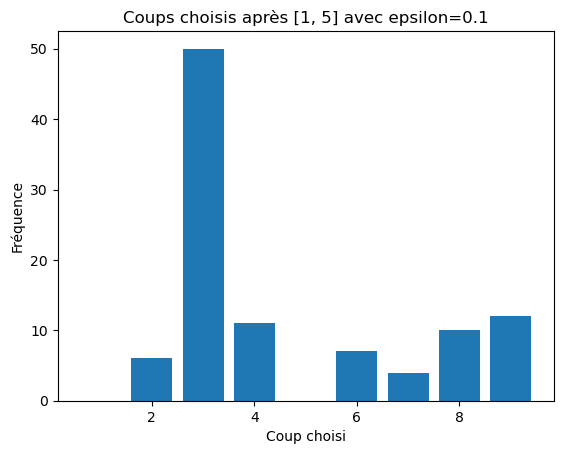

In [4]:
# Dictionnaire d'états et leurs valeurs associées
etats_et_valeurs = {
    (1,): 0.1,          # État après le coup 1
    (1, 5, 9): 0.02,   # État après les coups 1, 5, puis 9
    (1, 5, 3): 0.4,    # État après les coups 1, 5, puis 3
    (2,): 0.1,          # État après le coup 2
    (2, 3, 1): 0.2,    # État après les coups 2, 3, puis 1
    (2, 3, 5): 0.5     # État après les coups 2, 3, puis 5
}

# Situation hypothétique : les coups 1 et 5 ont été joués
etat_actuel = [1, 5]
coups_possibles = [2, 3, 4, 6, 7, 8, 9]

# Simuler 100 choix de coups pour voir la distribution
coups_choisis = []
for _ in range(100):
    coup = choisir_coup(coups_possibles, etat_actuel, etats_et_valeurs, epsilon=0.5)
    coups_choisis.append(coup)

# Visualisation avec un histogramme
import matplotlib.pyplot as plt

plt.hist(coups_choisis, bins=range(1, 11), align='left', rwidth=0.8)
plt.title('Coups choisis après [1, 5] avec epsilon=0.1')
plt.xlabel('Coup choisi')
plt.ylabel('Fréquence')
plt.show()

In [5]:
def attribuer_recompense(etats_et_valeurs, etats, recompense, taux_apprentissage=0.5, facteur_reduction=0.9):
    """
    Met à jour les valeurs associées à chaque état en fonction de la récompense obtenue.
    Arguments:
    -----------
    etats_et_valeurs : dict
        Dictionnaire stockant les valeurs de chaque état rencontré.
    etats : list
        Liste des états traversés pendant la partie (chaque état est une séquence de coups).
    recompense : float
        Récompense finale (1 pour victoire, -1 pour défaite, 0.5 pour nul).
    taux_apprentissage : float, optionnel (défaut=0.5)
        Alpha (α) : Vitesse d'apprentissage.
    facteur_reduction : float, optionnel (défaut=0.9)
        Gamma (γ) : Importance des récompenses éloignées.
    Retourne:
    -----------
    dict
        Dictionnaire mis à jour avec les nouvelles valeurs.
    """
    for etat in reversed(etats):
        etat_tuple = tuple(etat)
        if etat_tuple in etats_et_valeurs:
            etats_et_valeurs[etat_tuple] += taux_apprentissage * (
                facteur_reduction * recompense - etats_et_valeurs[etat_tuple]
            )
        elif etat != etats[-1]:
            etats_et_valeurs[etat_tuple] = taux_apprentissage * facteur_reduction * recompense
        else:
            etats_et_valeurs[etat_tuple] = recompense
        recompense = etats_et_valeurs[etat_tuple]
    return etats_et_valeurs

In [6]:
# Simulation d'une partie
etats = [
    [1],            # Joueur 1 joue le coup 1
    [1, 5],        # Joueur 2 joue le coup 5
    [1, 5, 3],     # Joueur 1 joue le coup 3
    [1, 5, 3, 7],  # Joueur 2 joue le coup 7
    [1, 5, 3, 7, 2]  # Joueur 1 joue le coup 2 (victoire)
]
etats_et_valeurs = {
    (1,): 0.0,
    (1, 5): 0.0,
    (1, 5, 3): 0.0,
    (1, 5, 3, 7): 0.0
}
recompense_finale = 1.0  # Victoire pour le joueur 1

# Afficher les valeurs avant mise à jour
print("Valeurs avant mise à jour :")
for etat, valeur in etats_et_valeurs.items():
    print(f"État {list(etat)} : {valeur:.3f}")

# Mettre à jour les valeurs
nouvelles_valeurs = attribuer_recompense(
    etats_et_valeurs, etats, recompense_finale, taux_apprentissage=0.5, facteur_reduction=0.9
)

# Afficher les valeurs après mise à jour
print("\nValeurs après mise à jour :")
for etat, valeur in nouvelles_valeurs.items():
    print(f"État {list(etat)} : {valeur:.3f}")

Valeurs avant mise à jour :
État [1] : 0.000
État [1, 5] : 0.000
État [1, 5, 3] : 0.000
État [1, 5, 3, 7] : 0.000

Valeurs après mise à jour :
État [1] : 0.041
État [1, 5] : 0.091
État [1, 5, 3] : 0.203
État [1, 5, 3, 7] : 0.450
État [1, 5, 3, 7, 2] : 1.000


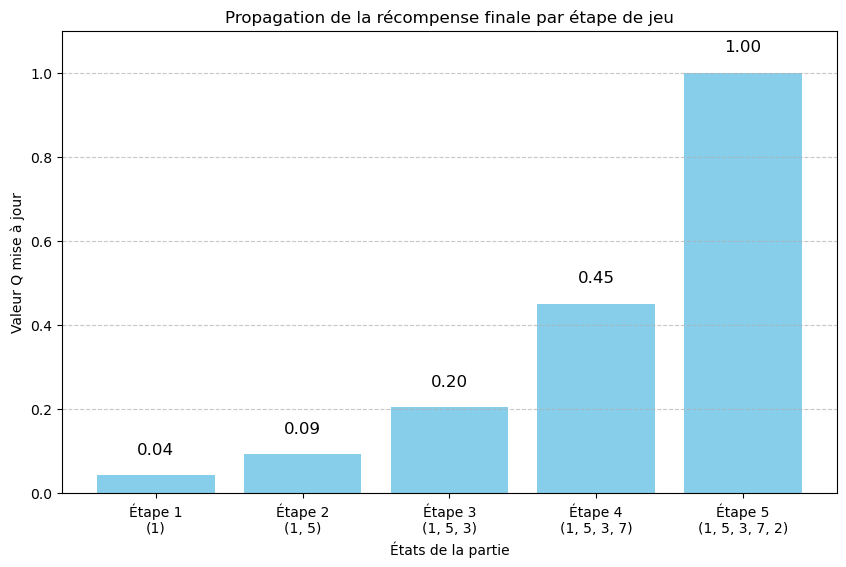

In [7]:
import matplotlib.pyplot as plt

# Préparation des données pour le graphique
labels = [f"Étape {i+1}\n({', '.join(map(str, etat))})" for i, etat in enumerate(etats)]
valeurs_a_tracer = [nouvelles_valeurs[tuple(etat)] for etat in etats]

# Création du graphique
plt.figure(figsize=(10, 6))
plt.bar(labels, valeurs_a_tracer, color='skyblue')
plt.xlabel("États de la partie")
plt.ylabel("Valeur Q mise à jour")
plt.title("Propagation de la récompense finale par étape de jeu")
plt.ylim(0, 1.1)
for i, v in enumerate(valeurs_a_tracer):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', color='black', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
def entrainement_autonome(nb_parties, strategie_j1, strategie_j2, epsilon_j1=0.1, epsilon_j2=0.1,
                         alpha_j1=0.2, alpha_j2=0.2, gamma_j1=0.9, gamma_j2=0.9,
                         afficher_partie=False, joueur1={}, joueur2={}):
    """
    Permet à deux joueurs (IA ou aléatoire) de s'entraîner en jouant l'un contre l'autre.

    Arguments:
    -----------
    nb_parties : int
        Nombre de parties à jouer
    strategie_j1, strategie_j2 : str
        Stratégie des joueurs ('rl' pour Q-Learning ou 'random' pour aléatoire)
    epsilon_j1, epsilon_j2 : float
        Taux d'exploration pour chaque joueur (défaut: 0.1)
    alpha_j1, alpha_j2 : float
        Taux d'apprentissage pour chaque joueur (défaut: 0.2)
    gamma_j1, gamma_j2 : float
        Facteur de réduction pour les récompenses éloignées (défaut: 0.9)
    afficher_partie : bool
        Si True, affiche certaines parties pour suivre l'évolution
    joueur1, joueur2 : dict
        Dictionnaires stockant les valeurs d'états pour chaque joueur

    Retourne:
    -----------
    tuple : (victoires_j1, victoires_j2, nuls, joueur1, joueur2)
        Historique des résultats et états mis à jour des joueurs
    """
    # Initialisation des listes pour suivre les résultats
    victoires_j1 = []  # 1 pour victoire, 0 sinon
    victoires_j2 = []  # 1 pour victoire, 0 sinon
    matchs_nuls = []   # 1 pour match nul, 0 sinon

    # Boucle principale d'entraînement
    for i in range(nb_parties):
        # Initialisation d'une nouvelle partie
        joueur_actuel = 1
        partie_en_cours = True
        jeu = Morpion()

        # Variables de suivi de la partie
        numero_coup = 1
        coups_possibles = [1, 2, 3, 4, 5, 6, 7, 8, 9]
        etat_actuel = []
        gagnant = ''

        # Listes pour stocker les états traversés par chaque joueur
        etats_j1 = []
        etats_j2 = []

        # Boucle d'une partie (maximum 9 coups)
        while numero_coup < 10:
            # Vérification si la partie est terminée
            if gagnant in ['X', 'O']:
                # Affichage périodique des parties
                if ((i+1) % 5000 == 0) and afficher_partie:
                    print(f'Partie numéro {i + 1}\\n')
                    jeu.afficher_plateau()
                break

            # Sélection du coup selon la stratégie du joueur actuel
            if joueur_actuel == 1:
                if strategie_j1 == 'rl':
                    coup = choisir_coup(coups_possibles, etat_actuel, joueur1, epsilon_j1)
                else:  # stratégie aléatoire
                    coup = np.random.choice(coups_possibles)
            else:
                if strategie_j2 == 'rl':
                    coup = choisir_coup(coups_possibles, etat_actuel, joueur2, epsilon_j2)
                else:  # stratégie aléatoire
                    coup = np.random.choice(coups_possibles)

            # Jouer le coup et mettre à jour l'état du jeu
            _, coups_possibles = jeu.jouer_coup(coup, joueur_actuel)
            gagnant = jeu.verifier_gagnant()

            # Mise à jour des états
            numero_coup += 1
            etat_actuel.append(coup)
            etats_j1.append(list(etat_actuel))
            etats_j2.append(list(etat_actuel))

            # Changement de joueur
            joueur_actuel = 3 - joueur_actuel  # Alterne entre 1 et 2

        # Attribution des récompenses selon le résultat
        if gagnant == 'O':  # Victoire J1
            joueur1 = attribuer_recompense(joueur1, etats_j1, 1, alpha_j1, gamma_j1)
            joueur2 = attribuer_recompense(joueur2, etats_j2, -1, alpha_j2, gamma_j2)
            victoires_j1.append(1)
            victoires_j2.append(0)
            matchs_nuls.append(0)
        elif gagnant == 'X':  # Victoire J2
            joueur2 = attribuer_recompense(joueur2, etats_j2, 1, alpha_j2, gamma_j2)
            joueur1 = attribuer_recompense(joueur1, etats_j1, -1, alpha_j1, gamma_j1)
            victoires_j1.append(0)
            victoires_j2.append(1)
            matchs_nuls.append(0)
        else:  # Match nul
            joueur1 = attribuer_recompense(joueur1, etats_j1, 0.5, alpha_j1, gamma_j1)
            joueur2 = attribuer_recompense(joueur2, etats_j2, 0.5, alpha_j2, gamma_j2)
            victoires_j1.append(0)
            victoires_j2.append(0)
            matchs_nuls.append(1)

    return victoires_j1, victoires_j2, matchs_nuls, joueur1, joueur2

def calculer_somme_cumulative(historique_victoires):
    """
    Calcule la somme cumulative des victoires pour visualiser la progression.

    Arguments:
    ----------
    historique_victoires : list
        Liste de 1 (victoire) et 0 (défaite/nul)

    Retourne:
    ----------
    tuple : (parties, somme_cumulative)
        Numéros des parties et somme cumulative des victoires
    """
    parties = np.arange(0, len(historique_victoires))
    somme_cumulative = []
    total = 0

    for i in range(len(parties)):
        total += historique_victoires[i]
        somme_cumulative.append(total)

    return parties + 1, np.array(somme_cumulative)

In [9]:
# Entraînement autonome des joueurs sur un grand nombre de parties
# Ici, nous lançons une session d'entraînement où deux joueurs aléatoires s'affrontent pendant 10^4 parties.

# Appel de la fonction d'entraînement avec les paramètres suivants :
# - nb_parties : Nombre total de parties à jouer (10 000 dans ce cas)
# - strategie_j1, strategie_j2 : Stratégies utilisées par chaque joueur ('random' signifie choix aléatoire des coups)
# - afficher_partie : Booléen indiquant si certaines parties doivent être affichées pour suivre l'évolution

# Les résultats retournés sont :
# - victoires_joueur_1 : Liste des victoires du joueur 1 (1 pour une victoire, 0 sinon)
# - victoires_joueur_2 : Liste des victoires du joueur 2 (1 pour une victoire, 0 sinon)
# - matchs_nuls : Liste des matchs nuls (1 pour un nul, 0 sinon)
# - joueur_1 : Dictionnaire contenant les valeurs d'états mis à jour pour le joueur 1
# - joueur_2 : Dictionnaire contenant les valeurs d'états mis à jour pour le joueur 2

victoires_joueur_1, victoires_joueur_2, matchs_nuls, joueur_1, joueur_2 = \
    entrainement_autonome(
        nb_parties=10**4,
        strategie_j1='random',
        strategie_j2='random',
        afficher_partie=True
    )

Partie numéro 5000\n


|     |     
  X  |  X  |  O
_____|_____|_____
     |     |     
  O  |  X  |  6
_____|_____|_____
     |     |     
  O  |  X  |  O
     |     |

Partie numéro 10000\n


|     |     
  X  |  O  |  X
_____|_____|_____
     |     |     
  O  |  X  |  6
_____|_____|_____
     |     |     
  X  |  O  |  O
     |     |

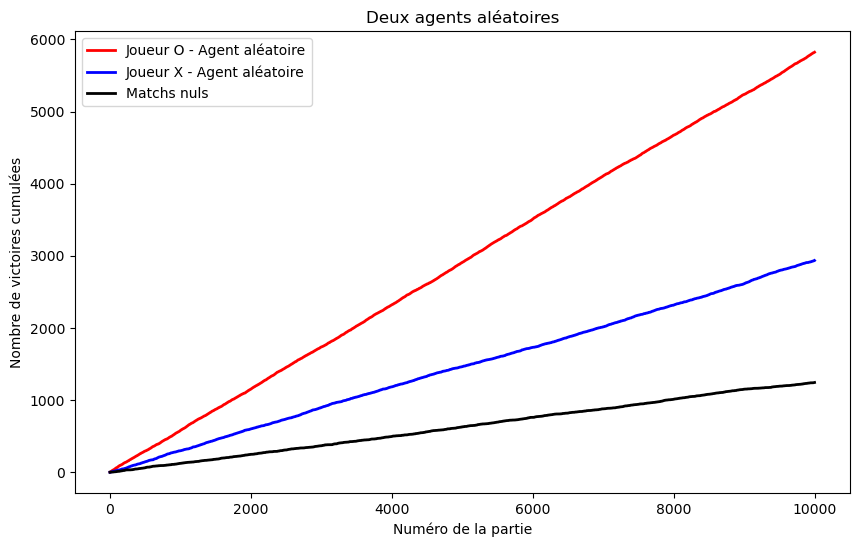

Pourcentage de victoires pour le joueur 1 (Agent aléatoire) : 58.22 %
Pourcentage de victoires pour le joueur 2 (Agent aléatoire) : 29.34 %
Pourcentage de matchs nuls : 12.44 %


In [10]:
# Calcul des sommes cumulatives pour chaque joueur et les matchs nuls
# La fonction `cum_sum` permet de calculer la progression cumulative des victoires au fil des parties.

# Pour le joueur 1 (joueur O)
parties_joueur_1, victoires_cumulees_joueur_1 = calculer_somme_cumulative(victoires_joueur_1)
# Pour le joueur 2 (joueur X)
parties_joueur_2, victoires_cumulees_joueur_2 = calculer_somme_cumulative(victoires_joueur_2)
# Pour les matchs nuls
parties_nuls, matchs_nuls_cumules = calculer_somme_cumulative(matchs_nuls)

# Création d'une figure pour visualiser les résultats
plt.figure(figsize=(10, 6))  # Définition de la taille de la figure

# Tracé des courbes de victoires cumulées pour chaque joueur et les matchs nuls
plt.plot(
    parties_joueur_1, victoires_cumulees_joueur_1,
    color='r', linewidth=2, label='Joueur O - Agent aléatoire'
)  # Courbe rouge pour le joueur O
plt.plot(
    parties_joueur_2, victoires_cumulees_joueur_2,
    color='b', linewidth=2, label='Joueur X - Agent aléatoire'
)  # Courbe bleue pour le joueur X
plt.plot(
    parties_nuls, matchs_nuls_cumules,
    color='k', linewidth=2, label='Matchs nuls'
)  # Courbe noire pour les matchs nuls

# Ajout du titre et des légendes
plt.title('Deux agents aléatoires')  # Titre du graphique
plt.xlabel('Numéro de la partie')  # Label de l'axe des abscisses
plt.ylabel('Nombre de victoires cumulées')  # Label de l'axe des ordonnées
plt.legend()  # Affichage de la légende

# Affichage du graphique
plt.show()

# Calcul et affichage des pourcentages de victoires et de matchs nuls
# Pourcentage de victoires pour le joueur 1
pourcentage_victoires_joueur_1 = np.round(sum(victoires_joueur_1) / len(victoires_joueur_1) * 100, 4)
print(f'Pourcentage de victoires pour le joueur 1 (Agent aléatoire) : {pourcentage_victoires_joueur_1} %')

# Pourcentage de victoires pour le joueur 2
pourcentage_victoires_joueur_2 = np.round(sum(victoires_joueur_2) / len(victoires_joueur_2) * 100, 4)
print(f'Pourcentage de victoires pour le joueur 2 (Agent aléatoire) : {pourcentage_victoires_joueur_2} %')

# Pourcentage de matchs nuls
pourcentage_matchs_nuls = np.round(sum(matchs_nuls) / len(matchs_nuls) * 100, 4)
print(f'Pourcentage de matchs nuls : {pourcentage_matchs_nuls} %')

In [11]:
# Entraînement autonome des joueurs sur un grand nombre de parties
# Ici, nous lançons une session d'entraînement entre un agent aléatoire et un agent d'apprentissage par renforcement

victoires_joueur_1, victoires_joueur_2, matchs_nuls, joueur_1, joueur_2 = \
    entrainement_autonome(
        nb_parties=10**4,
        strategie_j1='rl',
        strategie_j2='random',
        afficher_partie=True
    )

Partie numéro 5000\n


|     |     
  1  |  2  |  X
_____|_____|_____
     |     |     
  O  |  O  |  O
_____|_____|_____
     |     |     
  X  |  8  |  9
     |     |

Partie numéro 10000\n


|     |     
  1  |  2  |  O
_____|_____|_____
     |     |     
  4  |  O  |  X
_____|_____|_____
     |     |     
  O  |  X  |  9
     |     |

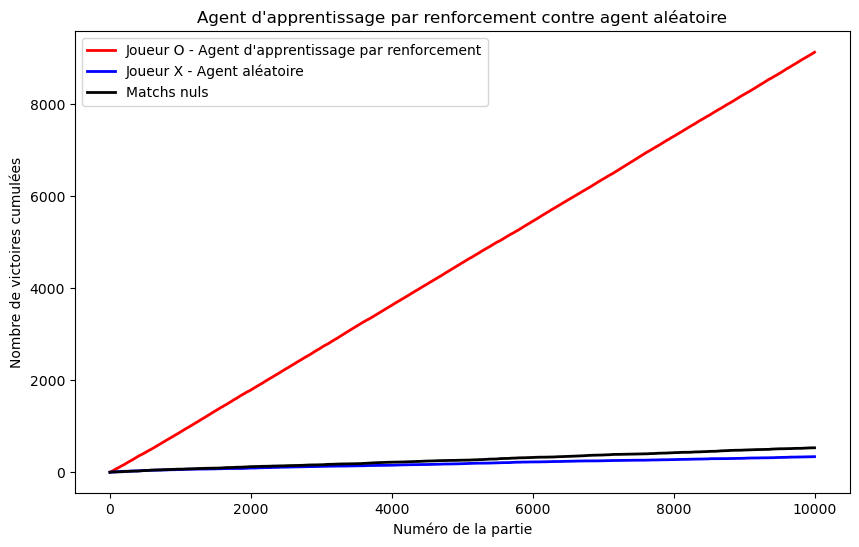

Pourcentage de victoires pour le joueur 1 (Agent d'apprentissage par renforcement) : 91.31 %
Pourcentage de victoires pour le joueur 2 (Agent aléatoire) : 3.38 %
Pourcentage de matchs nuls : 5.31 %


In [12]:
# Tracer les résultats de l'entraînement

# Calcul des sommes cumulatives pour chaque joueur et les matchs nuls
# La fonction `cum_sum` permet de calculer la progression cumulative des victoires au fil des parties.

# Pour le joueur 1 (joueur O - Agent d'apprentissage par renforcement)
parties_joueur_1, victoires_cumulees_joueur_1 = calculer_somme_cumulative(victoires_joueur_1)

# Pour le joueur 2 (joueur X - Agent aléatoire)
parties_joueur_2, victoires_cumulees_joueur_2 = calculer_somme_cumulative(victoires_joueur_2)

# Pour les matchs nuls
parties_nuls, matchs_nuls_cumules = calculer_somme_cumulative(matchs_nuls)

# Création d'une figure pour visualiser les résultats
plt.figure(figsize=(10, 6))  # Définition de la taille de la figure

# Tracé des courbes de victoires cumulées pour chaque joueur et les matchs nuls
plt.plot(
    parties_joueur_1, victoires_cumulees_joueur_1,
    color='r', linewidth=2, label='Joueur O - Agent d\'apprentissage par renforcement'
)  # Courbe rouge pour le joueur O (RL agent)
plt.plot(
    parties_joueur_2, victoires_cumulees_joueur_2,
    color='b', linewidth=2, label='Joueur X - Agent aléatoire'
)  # Courbe bleue pour le joueur X (Random agent)
plt.plot(
    parties_nuls, matchs_nuls_cumules,
    color='k', linewidth=2, label='Matchs nuls'
)  # Courbe noire pour les matchs nuls

# Ajout du titre et des légendes
plt.title('Agent d\'apprentissage par renforcement contre agent aléatoire')  # Titre du graphique
plt.xlabel('Numéro de la partie')  # Label de l'axe des abscisses
plt.ylabel('Nombre de victoires cumulées')  # Label de l'axe des ordonnées
plt.legend()  # Affichage de la légende

# Affichage du graphique
plt.show()

# Calcul et affichage des pourcentages de victoires et de matchs nuls
# Pourcentage de victoires pour le joueur 1 (Agent d'apprentissage par renforcement)
pourcentage_victoires_joueur_1 = np.round(sum(victoires_joueur_1) / len(victoires_joueur_1) * 100, 4)
print(f'Pourcentage de victoires pour le joueur 1 (Agent d\'apprentissage par renforcement) : {pourcentage_victoires_joueur_1} %')

# Pourcentage de victoires pour le joueur 2 (Agent aléatoire)
pourcentage_victoires_joueur_2 = np.round(sum(victoires_joueur_2) / len(victoires_joueur_2) * 100, 4)
print(f'Pourcentage de victoires pour le joueur 2 (Agent aléatoire) : {pourcentage_victoires_joueur_2} %')

# Pourcentage de matchs nuls
pourcentage_matchs_nuls = np.round(sum(matchs_nuls) / len(matchs_nuls) * 100, 4)
print(f'Pourcentage de matchs nuls : {pourcentage_matchs_nuls} %')

In [13]:
# Entraînement autonome des joueurs sur un grand nombre de parties
# Ici, nous lançons une session d'entraînement entre deux agents d'apprentissage par renforcement

victoires_joueur_1, victoires_joueur_2, matchs_nuls, joueur_1, joueur_2 = \
    entrainement_autonome(
        nb_parties=10**4,
        strategie_j1='rl',
        strategie_j2='rl',
        afficher_partie=True
    )

Partie numéro 10000\n


|     |     
  O  |  X  |  X
_____|_____|_____
     |     |     
  X  |  O  |  6
_____|_____|_____
     |     |     
  O  |  8  |  O
     |     |

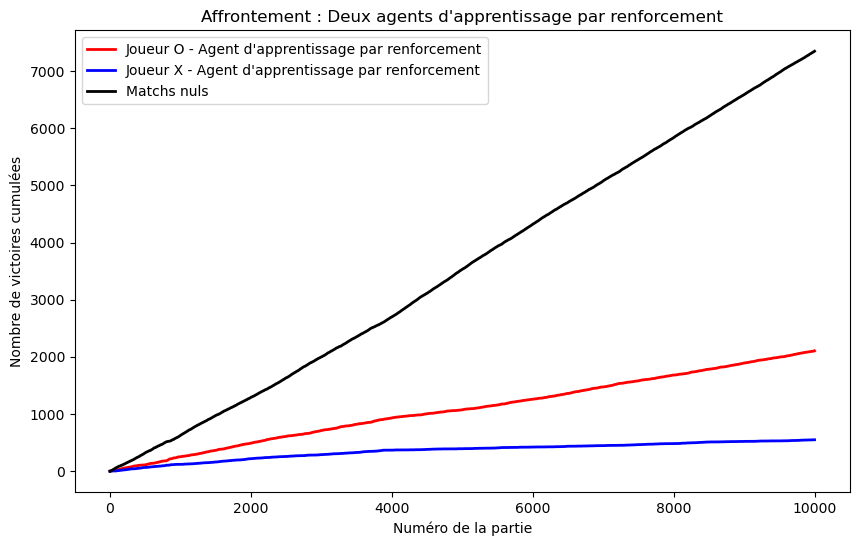

Pourcentage de victoires pour le joueur 1 (Agent d'apprentissage par renforcement) : 21.04 %
Pourcentage de victoires pour le joueur 2 (Agent d'apprentissage par renforcement) : 5.5 %
Pourcentage de matchs nuls : 73.46 %


In [14]:
# Tracer les résultats de l'affrontement entre deux agents d'apprentissage par renforcement

# Calcul des sommes cumulatives pour chaque joueur et les matchs nuls
# La fonction `cum_sum` permet de calculer la progression cumulative des victoires au fil des parties.

# Pour le joueur 1 (joueur O - Agent d'apprentissage par renforcement)
parties_joueur_1, victoires_cumulees_joueur_1 = calculer_somme_cumulative(victoires_joueur_1)

# Pour le joueur 2 (joueur X - Agent d'apprentissage par renforcement)
parties_joueur_2, victoires_cumulees_joueur_2 = calculer_somme_cumulative(victoires_joueur_2)

# Pour les matchs nuls
parties_nuls, matchs_nuls_cumules = calculer_somme_cumulative(matchs_nuls)

# Création d'une figure pour visualiser les résultats
plt.figure(figsize=(10, 6))  # Définition de la taille de la figure

# Tracé des courbes de victoires cumulées pour chaque joueur et les matchs nuls
plt.plot(
    parties_joueur_1, victoires_cumulees_joueur_1,
    color='r', linewidth=2, label='Joueur O - Agent d\'apprentissage par renforcement'
)  # Courbe rouge pour le joueur O (RL agent)
plt.plot(
    parties_joueur_2, victoires_cumulees_joueur_2,
    color='b', linewidth=2, label='Joueur X - Agent d\'apprentissage par renforcement'
)  # Courbe bleue pour le joueur X (RL agent)
plt.plot(
    parties_nuls, matchs_nuls_cumules,
    color='k', linewidth=2, label='Matchs nuls'
)  # Courbe noire pour les matchs nuls

# Ajout du titre et des légendes
plt.title('Affrontement : Deux agents d\'apprentissage par renforcement')  # Titre du graphique
plt.xlabel('Numéro de la partie')  # Label de l'axe des abscisses
plt.ylabel('Nombre de victoires cumulées')  # Label de l'axe des ordonnées
plt.legend()  # Affichage de la légende

# Affichage du graphique
plt.show()

# Calcul et affichage des pourcentages de victoires et de matchs nuls
# Pourcentage de victoires pour le joueur 1 (Agent d'apprentissage par renforcement)
pourcentage_victoires_joueur_1 = np.round(sum(victoires_joueur_1) / len(victoires_joueur_1) * 100, 4)
print(f'Pourcentage de victoires pour le joueur 1 (Agent d\'apprentissage par renforcement) : {pourcentage_victoires_joueur_1} %')

# Pourcentage de victoires pour le joueur 2 (Agent d'apprentissage par renforcement)
pourcentage_victoires_joueur_2 = np.round(sum(victoires_joueur_2) / len(victoires_joueur_2) * 100, 4)
print(f'Pourcentage de victoires pour le joueur 2 (Agent d\'apprentissage par renforcement) : {pourcentage_victoires_joueur_2} %')

# Pourcentage de matchs nuls
pourcentage_matchs_nuls = np.round(sum(matchs_nuls) / len(matchs_nuls) * 100, 4)
print(f'Pourcentage de matchs nuls : {pourcentage_matchs_nuls} %')

In [ ]:
from morpion import Morpion
import matplotlib.pyplot as plt
import numpy as np
import random
from IPython.display import clear_output

# Entraînement entre deux agents RL
# Phase 1 : Entraînement initial entre deux agents aléatoires
victoires_joueur_1, victoires_joueur_2, matchs_nuls, joueur_1, joueur_2 = \
    entrainement_autonome(10**5, 'random', 'random')

# Phase 2 : Entraînement d'un agent RL contre un agent aléatoire (joueur 1 est RL, joueur 2 est aléatoire)
victoires_joueur_1, victoires_joueur_2, matchs_nuls, joueur_1, joueur_2 = \
    entrainement_autonome(10**5, 'rl', 'random', joueur1=joueur_1, joueur2=joueur_2)

# Phase 3 : Entraînement d'un agent aléatoire contre un agent RL (joueur 1 est aléatoire, joueur 2 est RL)
victoires_joueur_1, victoires_joueur_2, matchs_nuls, joueur_1, joueur_2 = \
    entrainement_autonome(10**5, 'random', 'rl', joueur1=joueur_1, joueur2=joueur_2)

# Phase 4 : Entraînement entre deux agents RL
victoires_joueur_1, victoires_joueur_2, matchs_nuls, joueur_1, joueur_2 = \
    entrainement_autonome(10**5, 'rl', 'rl', joueur1=joueur_1, joueur2=joueur_2)

# Initialisation d'une nouvelle partie entre un joueur humain et un agent entraîné
joueur_actuel = 1  # Le joueur 1 commence (l'agent entraîné)
partie = Morpion()  # Création d'une instance du jeu du morpion

# Valeurs initiales pour la partie
numero_coup = 1  # Numéro du coup actuel
coups_possibles = [1, 2, 3, 4, 5, 6, 7, 8, 9]  # Liste des coups possibles au début de la partie
etat_actuel = []  # État actuel du plateau (liste des coups joués)
gagnant = ''  # Variable pour stocker le nom du gagnant ('X', 'O' ou vide si pas de gagnant)

# Boucle principale de la partie
while numero_coup <= 10:  # Maximum 9 coups + 1 pour éviter les erreurs
    clear_output(wait=True)  # Efface la sortie précédente pour afficher à jour le plateau
    partie.afficher_plateau(gagnant)  # Affiche l'état actuel du plateau et le gagnant (si applicable)

    # Vérifie si la partie est terminée
    if gagnant == 'X':  # Si le joueur humain a gagné
        break
    elif gagnant == 'O':  # Si l'agent a gagné
        break
    if numero_coup == 10:  # Si tous les coups ont été joués sans vainqueur
        break

    # Choix du coup en fonction du joueur actuel
    if joueur_actuel == 1:  # Tour de l'agent entraîné
        coup = choisir_coup(coups_possibles, etat_actuel, joueur_1, 0)  # Choix du coup selon la stratégie RL
        _, coups_possibles = partie.jouer_coup(coup, joueur_actuel)  # Joue le coup et met à jour les coups possibles

    elif joueur_actuel == 2:  # Tour du joueur humain
        coup = int(input('Entrez le numéro de la case (1-9) : '))  # Demande au joueur humain de choisir un coup
        _, coups_possibles = partie.jouer_coup(coup, joueur_actuel)  # Joue le coup et met à jour les coups possibles

    # Vérifie s'il y a un gagnant après ce coup
    gagnant = partie.verifier_gagnant()

    # Incrémente le compteur de coups
    numero_coup += 1

    # Change de joueur
    if joueur_actuel == 1:
        joueur_actuel = 2  # Passage au joueur humain
    elif joueur_actuel == 2:
        joueur_actuel = 1  # Retour à l'agent entraîné